In [1]:
pip install emcee corner

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Problem 1
import numpy as np

# Constants
G = 6.674e-11  # m^3 kg^-1 s^-2
M_sun = 1.989e30  # kg
M_jup = 1.898e27  # kg
M_earth = 5.972e24  # kg
day_to_s = 86400  # s

# Derive conversion factor for practical units
factor = (2 * np.pi * G)**(1/3) * day_to_s**(-1/3) * M_jup / (M_sun**(2/3))

print(f"Equation 1 in practical units:")
print(f"K = {factor:.2f} * P^(-1/3) * (M_P sin i / M_J) * (M_star / M_sun)^(-2/3) [m/s]")

# Calculate K for earth
P_earth = 365.25  # days
M_earth_in_Mjup = M_earth / M_jup
K_earth = factor * (P_earth**(-1/3)) * M_earth_in_Mjup * 1.0 / (1.0**(2/3))

print(f"Earth:")
print(f"K = {K_earth:.3f} m/s")
print()

# Calculate K for jupiter
P_jupiter = 4332.59  # days
M_jupiter_Mjup = 1.0
K_jupiter = factor * (P_jupiter**(-1/3)) * M_jupiter_Mjup * 1.0 / (1.0**(2/3))

print(f"Jupiter:")
print(f"K = {K_jupiter:.3f} m/s")

Equation 1 in practical units:
K = 203.18 * P^(-1/3) * (M_P sin i / M_J) * (M_star / M_sun)^(-2/3) [m/s]
Earth:
K = 0.089 m/s

Jupiter:
K = 12.464 m/s


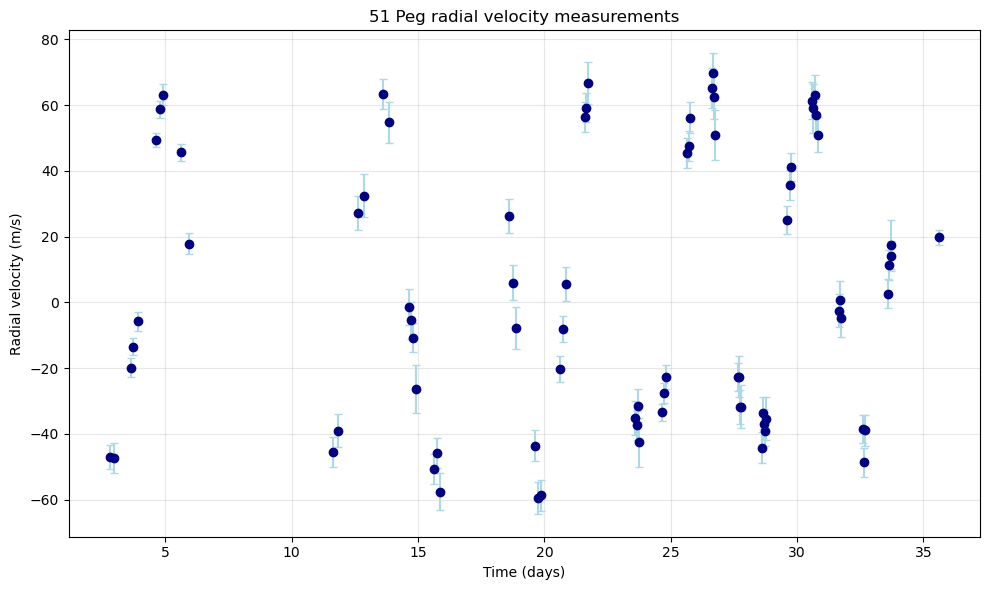

Visual estimates: P ≈ 4.2 days, K ≈ 55.0 m/s


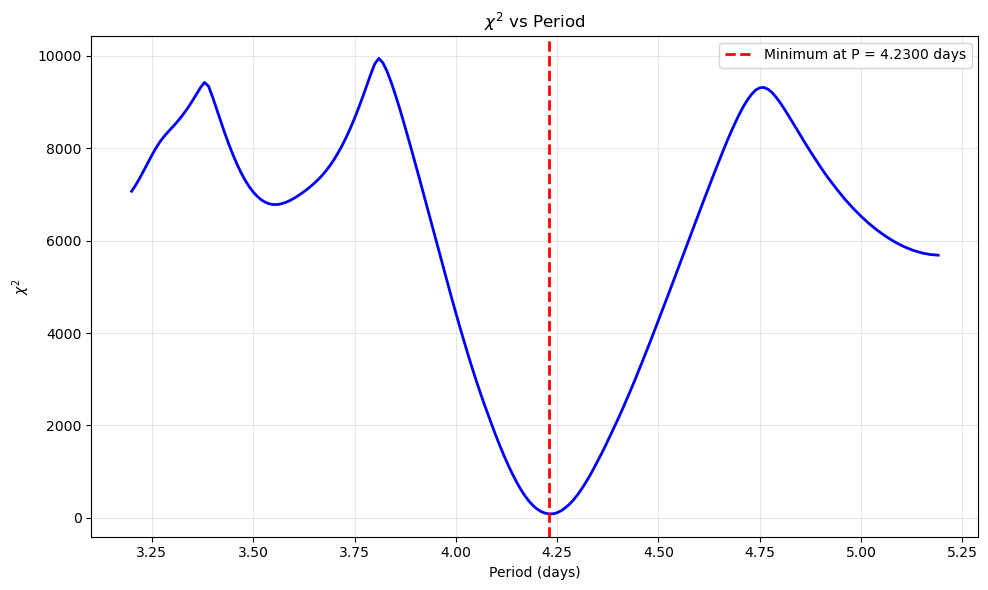

Best-fit parameters:
P  = 4.233400 days
K  = 56.60 m/s
f0 = 0.7200
v0 = 7.59 m/s
χ² = 76.48


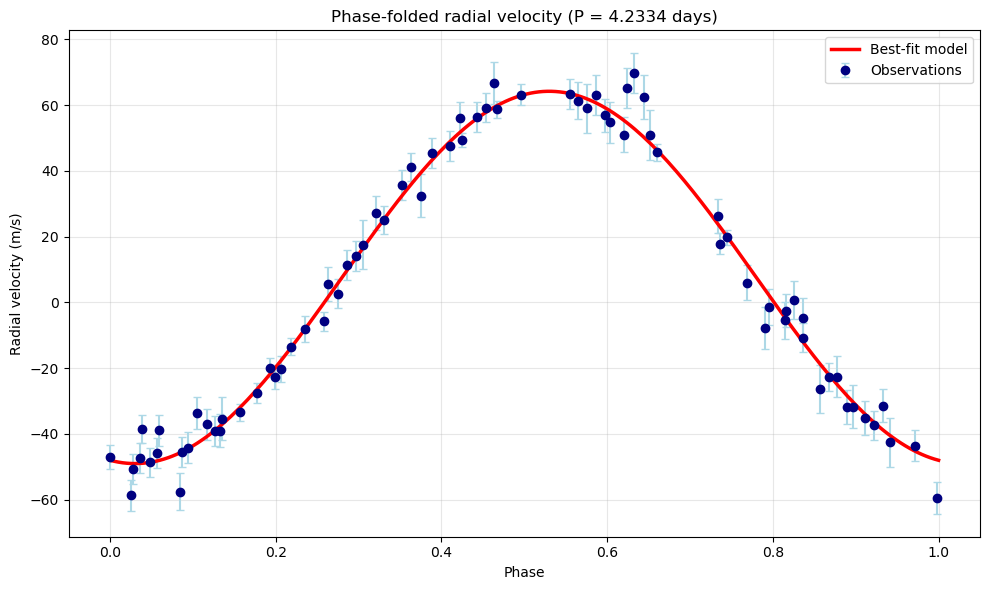

Minimal planet mass: M_P sin(i) = 0.483 M_Jupiter


In [3]:
# Problem 2
import numpy as np
import matplotlib.pyplot as plt

# Load data
data = np.loadtxt('51Peg_mayorqueloz95_alop2025_2026.csv', delimiter=',', skiprows=1)
t = data[:, 0]
vrad = data[:, 1]
sigma_vrad = data[:, 2]
t0 = t[0]

# Plot vrad against time
plt.figure(figsize=(10, 6))
plt.errorbar(t, vrad, yerr=sigma_vrad, fmt='o', color='navy', ecolor='lightblue', capsize=3)
plt.xlabel('Time (days)')
plt.ylabel('Radial velocity (m/s)')
plt.title('51 Peg radial velocity measurements')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Approximate estimates by eye
P_visual = 4.2
K_visual = 55.0

print(f"Visual estimates: P ≈ {P_visual} days, K ≈ {K_visual} m/s")

# Model function
def radial_velocity_model(t, K, P, f0, v0, t_ref):
    f = (t - t_ref) / P
    return K * np.sin(2 * np.pi * (f + f0)) + v0

# Chi-squared function
def chi_squared(K, P, f0, v0, t, vrad_obs, sigma_vrad, t_ref):
    vrad_model = radial_velocity_model(t, K, P, f0, v0, t_ref)
    return np.sum(((vrad_obs - vrad_model) / sigma_vrad)**2)

# Coarsed grid search
v0_visual = np.mean(vrad)
P_range = np.arange(P_visual - 1, P_visual + 1, 0.01)
K_range = np.arange(K_visual - 10, K_visual + 10, 1)
f0_range = np.arange(0, 1, 0.01)
v0_range = np.arange(v0_visual - 20, v0_visual + 20, 2)

chi2_min_P = np.zeros(len(P_range))
best_params_P = []

for i, P in enumerate(P_range):
    chi2_min = np.inf
    best_K, best_f0, best_v0 = None, None, None
    
    for K in K_range:
        for f0 in f0_range:
            for v0 in v0_range:
                chi2 = chi_squared(K, P, f0, v0, t, vrad, sigma_vrad, t0)
                if chi2 < chi2_min:
                    chi2_min = chi2
                    best_K, best_f0, best_v0 = K, f0, v0
    
    chi2_min_P[i] = chi2_min
    best_params_P.append({'P': P, 'K': best_K, 'f0': best_f0, 'v0': best_v0})

best_idx = np.argmin(chi2_min_P)
best_params = best_params_P[best_idx]

# Plot chi-squared vs period
plt.figure(figsize=(10, 6))
plt.plot(P_range, chi2_min_P, 'b-', linewidth=2)
plt.axvline(best_params['P'], color='red', linestyle='--', linewidth=2, label=f"Minimum at P = {best_params['P']:.4f} days")
plt.xlabel('Period (days)')
plt.ylabel('$\\chi^2$')
plt.title('$\\chi^2$ vs Period')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chi2_vs_period.png')
plt.show()

# Fine grid search
P_best = best_params['P']
K_best = best_params['K']
f0_best = best_params['f0']
v0_best = best_params['v0']

P_range_fine = np.arange(P_best - 0.05, P_best + 0.05, 0.0001)
K_range_fine = np.arange(K_best - 2, K_best + 2, 0.1)
f0_range_fine = np.arange(max(0, f0_best - 0.05), min(1, f0_best + 0.05), 0.001)
v0_range_fine = np.arange(v0_best - 2, v0_best + 2, 0.1)

chi2_min_P_fine = np.zeros(len(P_range_fine))
best_params_P_fine = []

for i, P in enumerate(P_range_fine):
    chi2_min = np.inf
    best_K, best_f0, best_v0 = None, None, None
    
    for K in K_range_fine:
        for f0 in f0_range_fine:
            for v0 in v0_range_fine:
                chi2 = chi_squared(K, P, f0, v0, t, vrad, sigma_vrad, t0)
                if chi2 < chi2_min:
                    chi2_min = chi2
                    best_K, best_f0, best_v0 = K, f0, v0
    
    chi2_min_P_fine[i] = chi2_min
    best_params_P_fine.append({'P': P, 'K': best_K, 'f0': best_f0, 'v0': best_v0})

best_idx_fine = np.argmin(chi2_min_P_fine)
best_params_fine = best_params_P_fine[best_idx_fine]
best_params_fine['chi2'] = chi2_min_P_fine[best_idx_fine]

P = best_params_fine['P']
K = best_params_fine['K']
f0 = best_params_fine['f0']
v0 = best_params_fine['v0']

print(f"Best-fit parameters:")
print(f"P  = {P:.6f} days")
print(f"K  = {K:.2f} m/s")
print(f"f0 = {f0:.4f}")
print(f"v0 = {v0:.2f} m/s")
print(f"χ² = {best_params_fine['chi2']:.2f}")

# Plot vrad against phase
phase = ((t - t0) / P) % 1.0
phase_model = np.linspace(0, 1, 200)
vrad_model = K * np.sin(2 * np.pi * (phase_model + f0)) + v0

plt.figure(figsize=(10, 6))
plt.errorbar(phase, vrad, yerr=sigma_vrad, fmt='o', color='navy', ecolor='lightblue', capsize=3, label='Observations', markersize=6)
plt.plot(phase_model, vrad_model, 'r-', linewidth=2.5, label='Best-fit model')
plt.xlabel('Phase')
plt.ylabel('Radial velocity (m/s)')
plt.title(f'Phase-folded radial velocity (P = {P:.4f} days)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('phase_folded.png')
plt.show()

# Calculate minimal mass
def calculate_planet_mass(K, P, M_star):
    G = 6.674e-11
    M_sun = 1.989e30
    M_jup = 1.898e27
    P_s = P * 86400
    M_star_kg = M_star * M_sun
    M_P_sini_kg = K * (M_star_kg**(2/3)) * ((P_s / (2 * np.pi * G))**(1/3))
    return M_P_sini_kg / M_jup

M_star = 1.11
M_P_sini = calculate_planet_mass(K, P, M_star)

print(f"Minimal planet mass: M_P sin(i) = {M_P_sini:.3f} M_Jupiter")

n = 73
χ² = 76.48
χ²_lim (95%) = 93.95
χ²_reduced = 1.048

χ² < χ²_lim: Cannot reject the hypothesis
The model provides a statistically acceptable fit


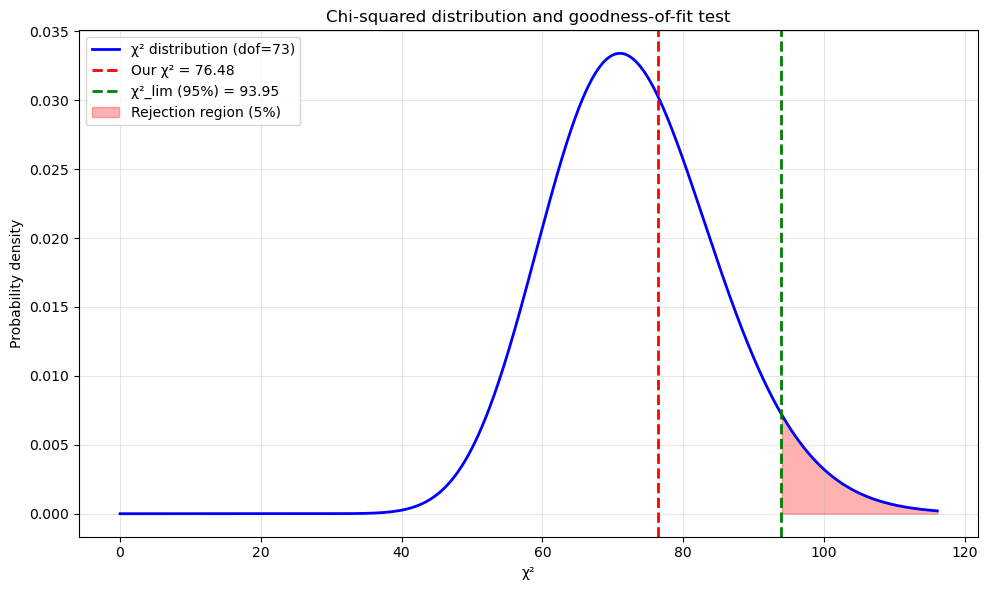

In [4]:
# Problem 3
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Load data
data = np.loadtxt('51Peg_mayorqueloz95_alop2025_2026.csv', delimiter=',', skiprows=1)
t = data[:, 0]
vrad = data[:, 1]
sigma_vrad = data[:, 2]
t0 = t[0]

# Model function
def radial_velocity_model(t, K, P, f0, v0, t_ref):
    f = (t - t_ref) / P
    return K * np.sin(2 * np.pi * (f + f0)) + v0

# Chi-squared function
def chi_squared(K, P, f0, v0, t, vrad_obs, sigma_vrad, t_ref):
    vrad_model = radial_velocity_model(t, K, P, f0, v0, t_ref)
    return np.sum(((vrad_obs - vrad_model) / sigma_vrad)**2)

# Best-fit parameters from problem 2
P_best = 4.233400
K_best = 56.60
f0_best = 0.7200
v0_best = 7.59

chi2_best = chi_squared(K_best, P_best, f0_best, v0_best, t, vrad, sigma_vrad, t0)

# Degrees of freedom
N = len(t)
m = 4
dof = N - m

# Chi-squared limit (5% sig)
alpha = 0.05
chi2_lim = chi2.ppf(1 - alpha, dof)

print(f"n = {dof}")
print(f"χ² = {chi2_best:.2f}")
print(f"χ²_lim (95%) = {chi2_lim:.2f}")
print(f"χ²_reduced = {chi2_best/dof:.3f}")

if chi2_best < chi2_lim:
    print(f"\nχ² < χ²_lim: Cannot reject the hypothesis")
    print("The model provides a statistically acceptable fit")
else:
    print(f"\nχ² > χ²_lim: Reject the hypothesis")
    print("The model does NOT provide a statistically acceptable fit")

# Plot chi-squared distribution
x = np.linspace(0, chi2.ppf(0.999, dof), 1000)
y = chi2.pdf(x, dof)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', linewidth=2, label=f'χ² distribution (dof={dof})')
plt.axvline(chi2_best, color='red', linestyle='--', linewidth=2, label=f'Our χ² = {chi2_best:.2f}')
plt.axvline(chi2_lim, color='green', linestyle='--', linewidth=2, label=f'χ²_lim (95%) = {chi2_lim:.2f}')
plt.fill_between(x[x > chi2_lim], 0, y[x > chi2_lim], alpha=0.3, color='red', label='Rejection region (5%)')
plt.xlabel('χ²')
plt.ylabel('Probability density')
plt.title('Chi-squared distribution and goodness-of-fit test')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chi2_distribution.png')
plt.show()

100%|██████████| 5000/5000 [00:03<00:00, 1404.77it/s]


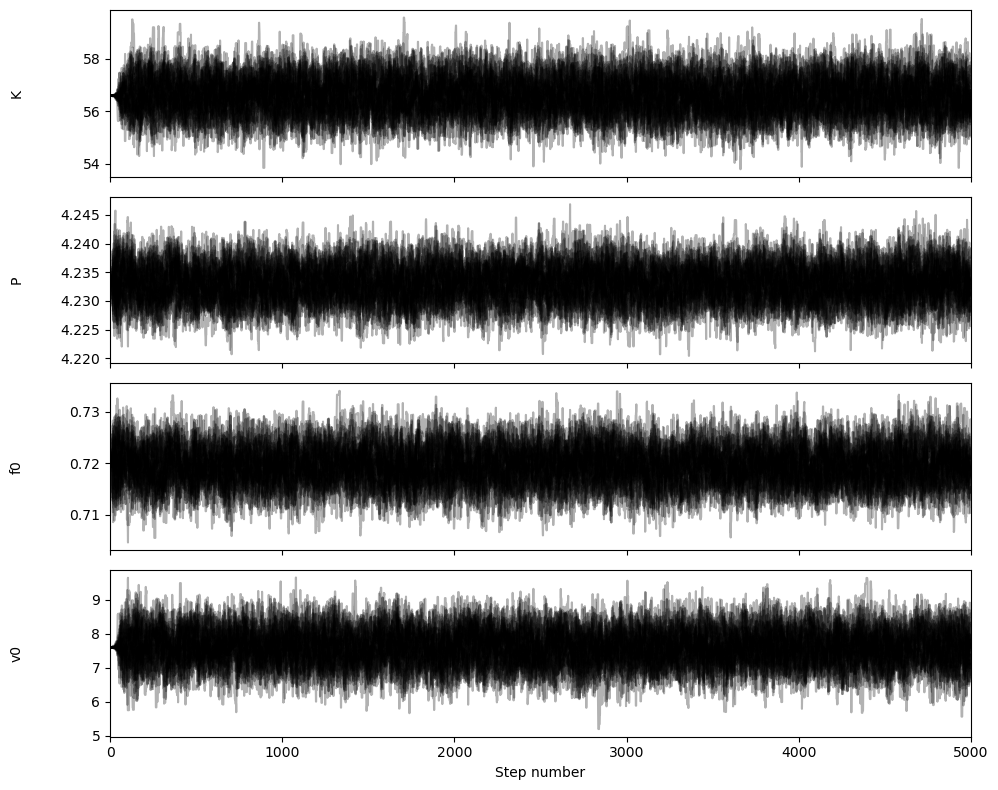

K = 56.608269 +0.712730 -0.698337
P = 4.233061 +0.003097 -0.003089
f0 = 0.719495 +0.003610 -0.003533
v0 = 7.589434 +0.516349 -0.516232


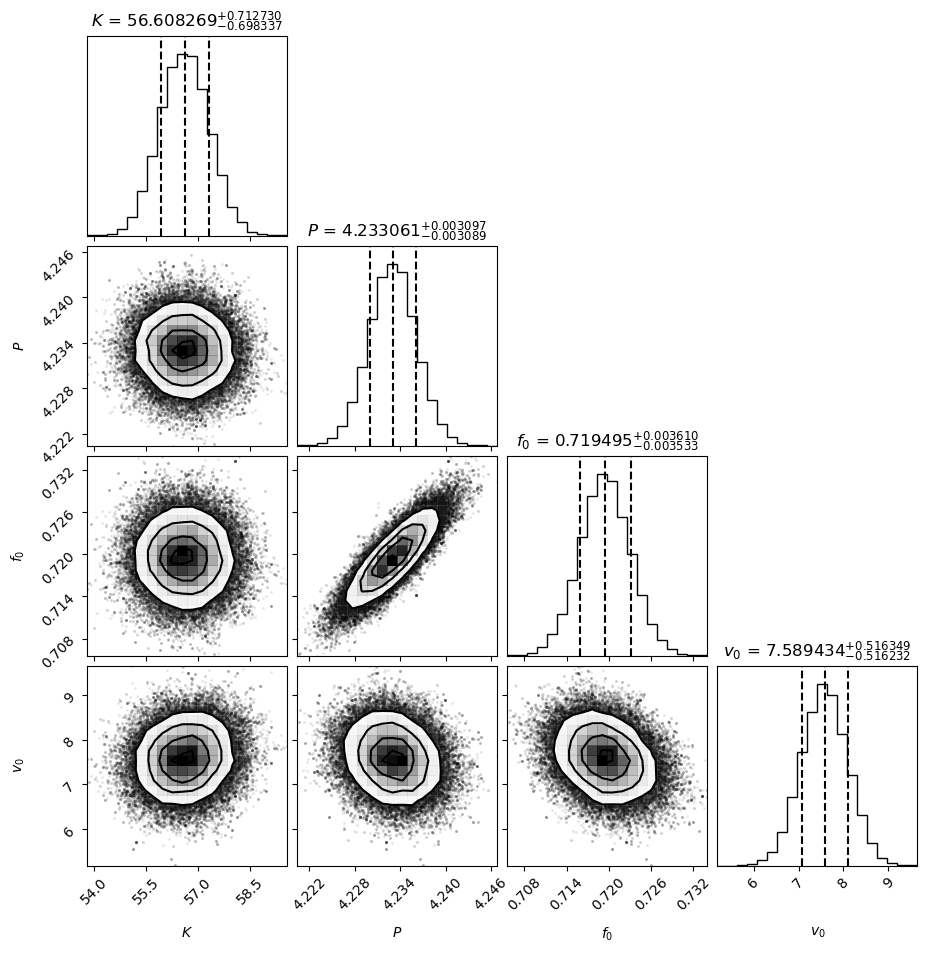

In [5]:
# Problem 4
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner

# Load data
data = np.loadtxt('51Peg_mayorqueloz95_alop2025_2026.csv', delimiter=',', skiprows=1)
t = data[:, 0]
vrad = data[:, 1]
sigma_vrad = data[:, 2]
t0 = t[0]

# Model function
def radial_velocity_model(t, K, P, f0, v0, t_ref):
    f = (t - t_ref) / P
    return K * np.sin(2 * np.pi * (f + f0)) + v0

# Log-likelihood
def log_likelihood(theta, t, vrad_obs, sigma_vrad, t_ref):
    K, P, f0, v0 = theta
    vrad_model = radial_velocity_model(t, K, P, f0, v0, t_ref)
    chi2 = np.sum(((vrad_obs - vrad_model) / sigma_vrad)**2)
    return -0.5 * chi2

# Log-prior (Gaussian)
def log_prior(theta):
    K, P, f0, v0 = theta
    
    # Prior centers from problem 2 best-fit
    K_center, K_sigma = 56.6, 10.0
    P_center, P_sigma = 4.2334, 0.5
    f0_center, f0_sigma = 0.72, 0.3
    v0_center, v0_sigma = 7.6, 20.0
    
    # Bounds
    if not (10 < K < 150):
        return -np.inf
    if not (3.0 < P < 6.0):
        return -np.inf
    if not (0 <= f0 <= 1):
        return -np.inf
    if not (-50 < v0 < 50):
        return -np.inf
    
    # Gaussian prior
    lp = 0.0
    lp += -0.5 * ((K - K_center) / K_sigma)**2
    lp += -0.5 * ((P - P_center) / P_sigma)**2
    lp += -0.5 * ((f0 - f0_center) / f0_sigma)**2
    lp += -0.5 * ((v0 - v0_center) / v0_sigma)**2
    
    return lp

# Log-probability
def log_probability(theta, t, vrad_obs, sigma_vrad, t_ref):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, t, vrad_obs, sigma_vrad, t_ref)

# Initial guess
theta_initial = np.array([56.6, 4.2334, 0.72, 7.6])

# Setup walkers
nwalkers = 32
ndim = 4
pos = theta_initial + 1e-4 * np.random.randn(nwalkers, ndim)

# Initialize sampler
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(t, vrad, sigma_vrad, t0))

# Run MCMC
nsteps = 5000
sampler.run_mcmc(pos, nsteps, progress=True)

# Get samples
samples = sampler.get_chain()

# Plot walker traces
fig, axes = plt.subplots(4, figsize=(10, 8), sharex=True)
labels = ["K", "P", "f0", "v0"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)
axes[-1].set_xlabel("Step number")
plt.tight_layout()
plt.savefig('walker_traces.png')
plt.show()

# Get new samples
burn_in = 1000
new_samples = sampler.get_chain(discard=burn_in, flat=True)



# Results
for i in range(ndim):
    mcmc = np.percentile(new_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"{labels[i]} = {mcmc[1]:.6f} +{q[1]:.6f} -{q[0]:.6f}")

# Corner plot
fig = corner.corner(new_samples, labels=["$K$", "$P$", "$f_0$", "$v_0$"], quantiles=[0.16, 0.5, 0.84], show_titles=True, title_fmt=".6f")
plt.savefig('corner_plot.png')
plt.show()

In [6]:
# Problem 5
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner

# Load data
data = np.loadtxt('51Peg_mayorqueloz95_alop2025_2026.csv', delimiter=',', skiprows=1)
t = data[:, 0]
vrad = data[:, 1]
sigma_vrad = data[:, 2]
t0 = t[0]

# Model function
def radial_velocity_model(t, K, P, f0, v0, t_ref):
    f = (t - t_ref) / P
    return K * np.sin(2 * np.pi * (f + f0)) + v0

# Log-likelihood
def log_likelihood(theta, t, vrad_obs, sigma_vrad, t_ref):
    K, P, f0, v0 = theta
    vrad_model = radial_velocity_model(t, K, P, f0, v0, t_ref)
    chi2 = np.sum(((vrad_obs - vrad_model) / sigma_vrad)**2)
    return -0.5 * chi2

# Log-prior
def log_prior(theta):
    K, P, f0, v0 = theta
    K_center, K_sigma = 56.6, 10.0
    P_center, P_sigma = 4.2334, 0.5
    f0_center, f0_sigma = 0.72, 0.3
    v0_center, v0_sigma = 7.6, 20.0
    
    if not (10 < K < 150):
        return -np.inf
    if not (3.0 < P < 6.0):
        return -np.inf
    if not (0 <= f0 <= 1):
        return -np.inf
    if not (-50 < v0 < 50):
        return -np.inf
    
    lp = 0.0
    lp += -0.5 * ((K - K_center) / K_sigma)**2
    lp += -0.5 * ((P - P_center) / P_sigma)**2
    lp += -0.5 * ((f0 - f0_center) / f0_sigma)**2
    lp += -0.5 * ((v0 - v0_center) / v0_sigma)**2
    return lp

# Log-probability
def log_probability(theta, t, vrad_obs, sigma_vrad, t_ref):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, t, vrad_obs, sigma_vrad, t_ref)

# Run MCMC
theta_initial = np.array([56.6, 4.2334, 0.72, 7.6])
nwalkers = 32
ndim = 4
pos = theta_initial + 1e-4 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(t, vrad, sigma_vrad, t0))

nsteps = 5000
sampler.run_mcmc(pos, nsteps, progress=True)

# Get new samples
burn_in = 1000
new_samples = sampler.get_chain(discard=burn_in, flat=True)

# Calculate planet mass for each sample
def calculate_planet_mass(K, P, M_star):
    G = 6.674e-11
    M_sun = 1.989e30
    M_jup = 1.898e27
    P_s = P * 86400
    M_star_kg = M_star * M_sun
    M_P_sini_kg = K * (M_star_kg**(2/3)) * ((P_s / (2 * np.pi * G))**(1/3))
    return M_P_sini_kg / M_jup

M_star = 1.11
M_P_samples = np.array([
    calculate_planet_mass(K, P, M_star)
    for K, P in zip(new_samples[:, 0], new_samples[:, 1])
])

# Calculate uncertainties
p16_M = np.percentile(M_P_samples, 16)
p50_M = np.percentile(M_P_samples, 50)
p84_M = np.percentile(M_P_samples, 84)
sigma_M = 0.5 * (p84_M - p16_M)

print(f"Uncertainty on minimal planet mass:")
print(f"M_P sin(i) = {p50_M:.3f} ± {sigma_M:.3f} M_Jupiter")

100%|██████████| 5000/5000 [00:03<00:00, 1327.42it/s]

Uncertainty on minimal planet mass:
M_P sin(i) = 0.483 ± 0.006 M_Jupiter
